In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv")

In [3]:
df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [4]:
print(df.isnull().sum()) 

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.50,202072.74,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.36,11.66,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.07,1.05,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.23,51.20,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.96,1.46,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.00,0.90,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.01,2.02,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.87,2.86,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.86,0.04,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.29,11.01,91.00,108.00,116.00,124.00,163.00


In [6]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [7]:
n1 = ['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides','family_history_diabetes', 'hypertension_history',
       'cardiovascular_history']

c1 = ['gender','ethnicity','employment_status','education_level', 'smoking_status','income_level']

In [8]:
target = 'diagnosed_diabetes'

In [9]:
df[target].value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [10]:
df[target].value_counts(normalize=True)

diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

In [11]:
df.shape
#

(700000, 26)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

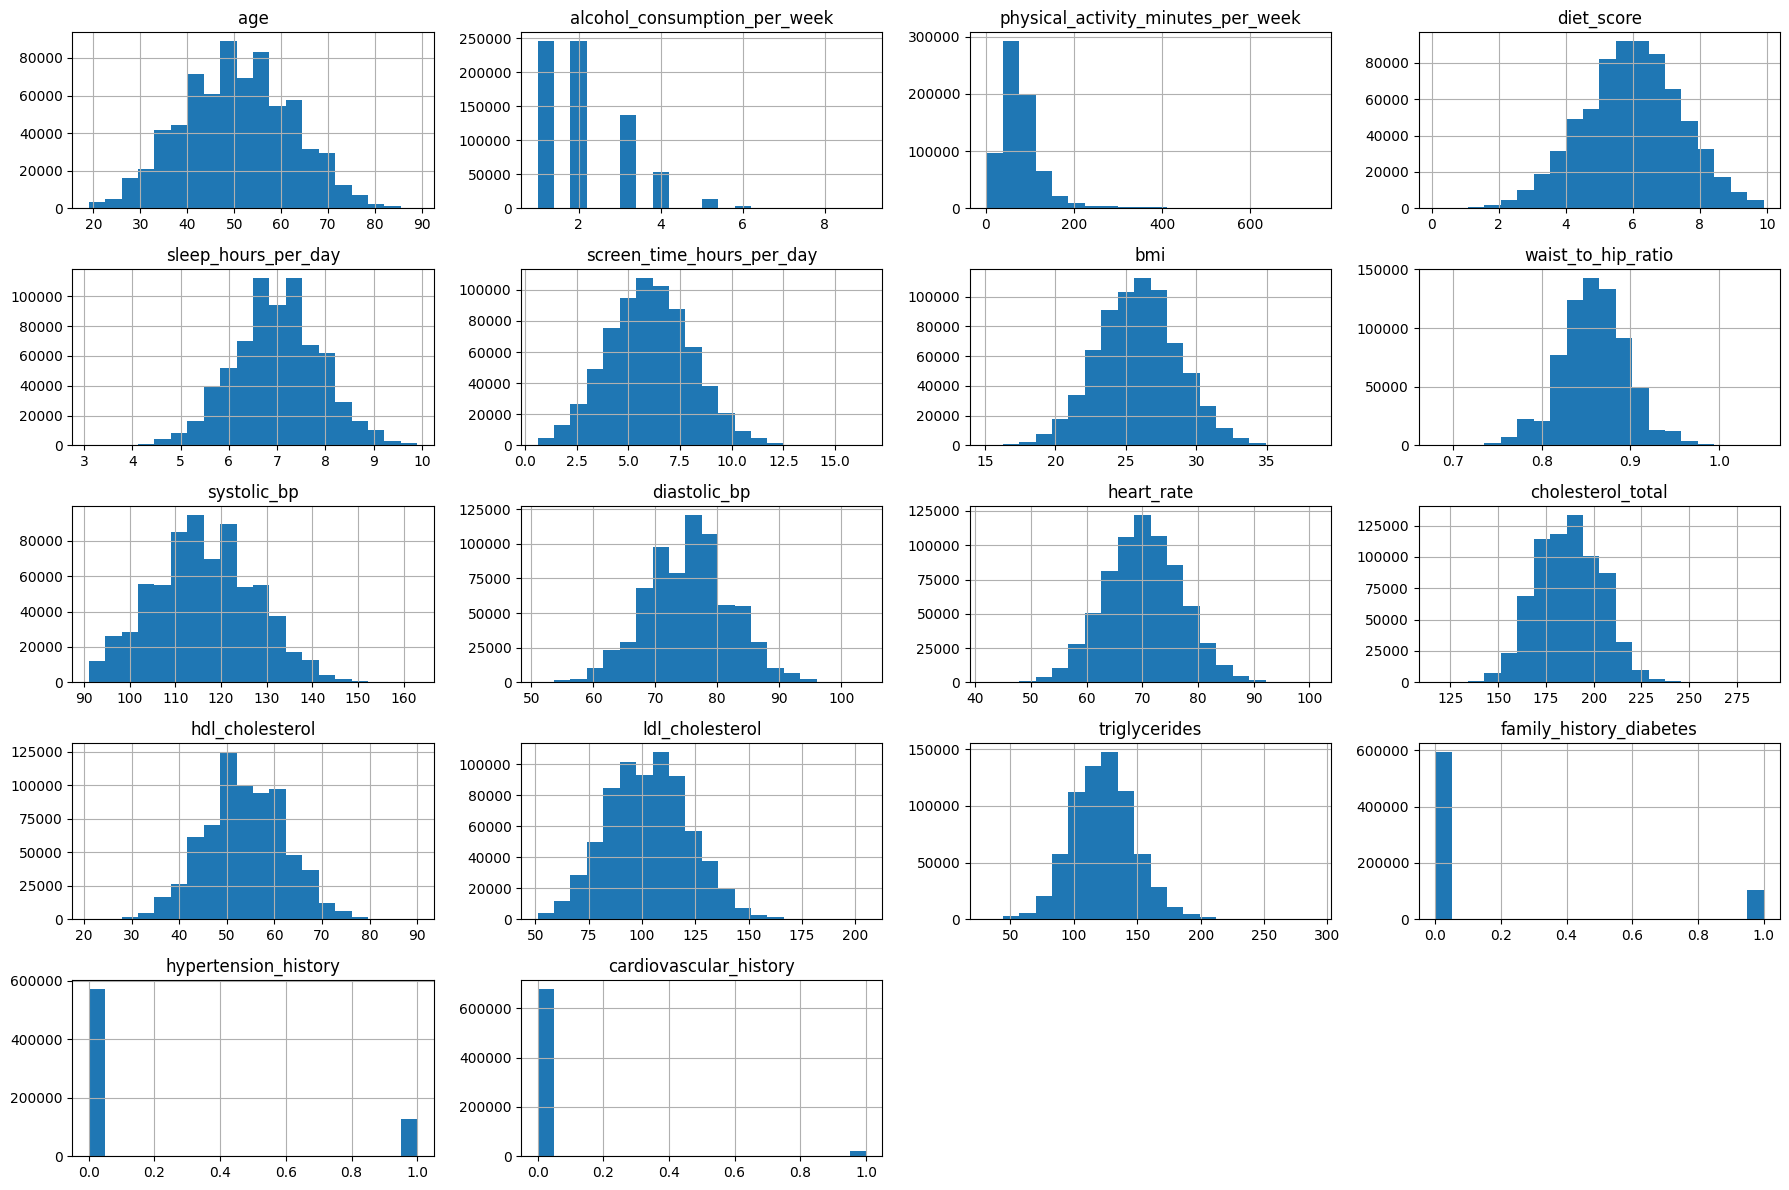

In [13]:
df[n1].hist(figsize=(18,12), bins=20)
plt.tight_layout()
plt.show()

In [14]:
for col in c1:
    print(df[col].value_counts())
    print('-'*40)

gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
----------------------------------------
ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
----------------------------------------
employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64
----------------------------------------
education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
----------------------------------------
smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64
----------------------------------------
income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64
----------------------------------------


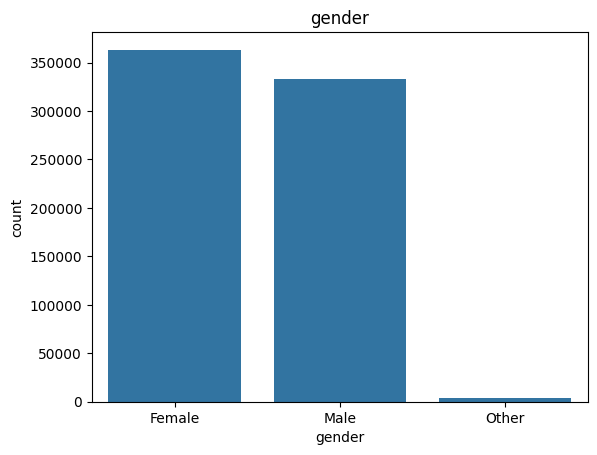

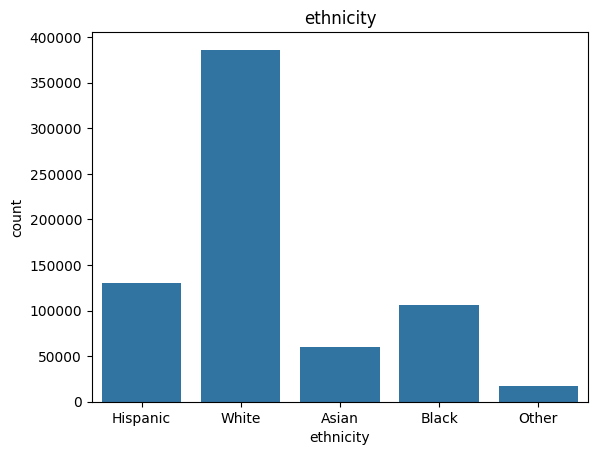

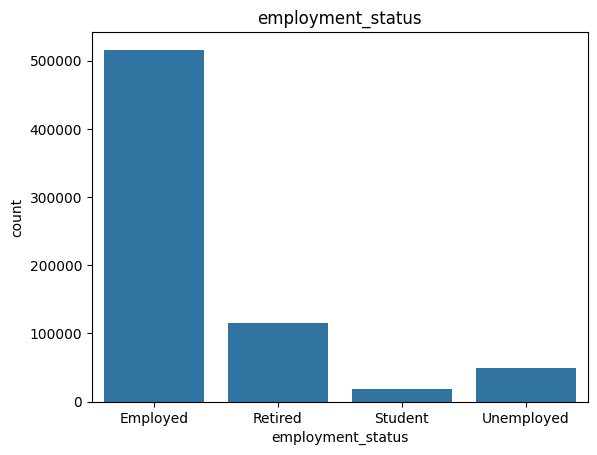

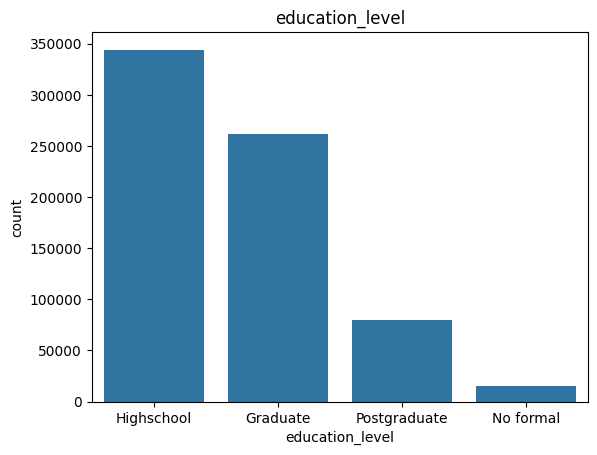

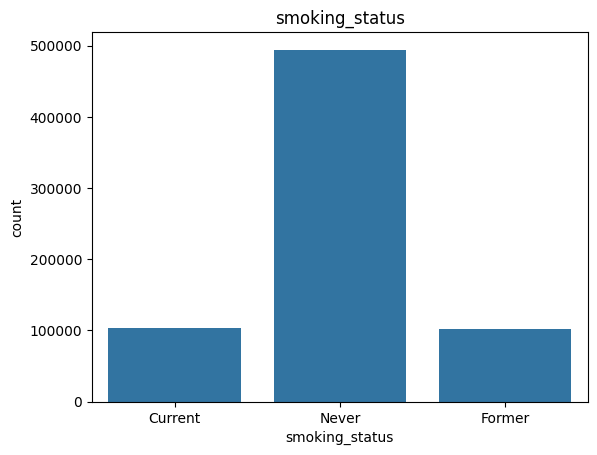

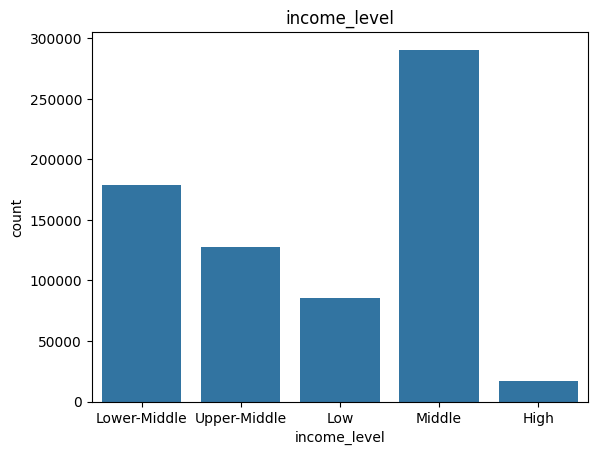

In [15]:
for col in c1:
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()


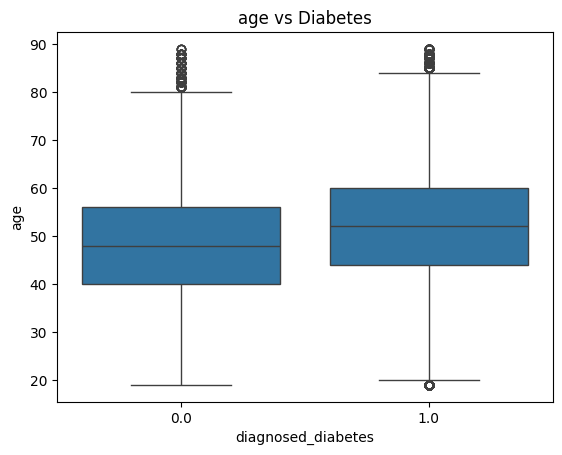

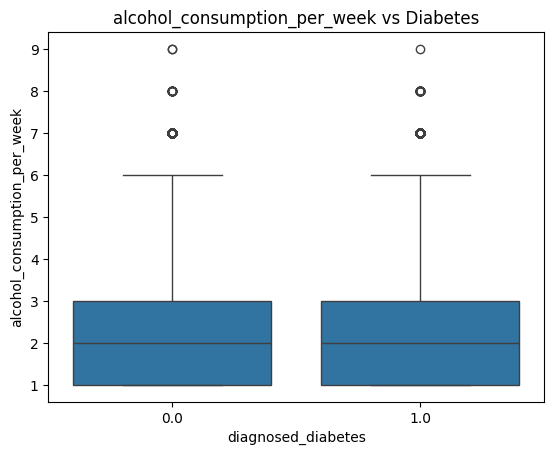

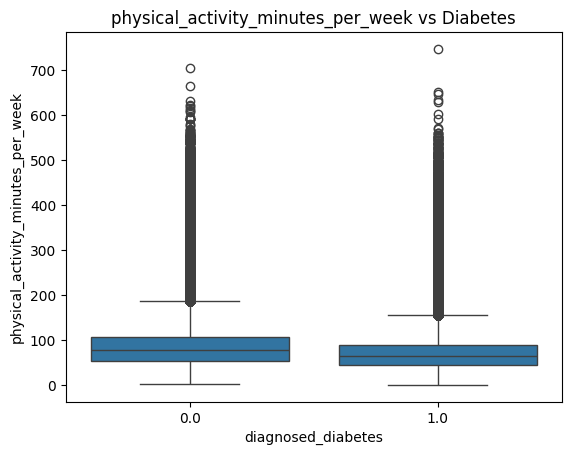

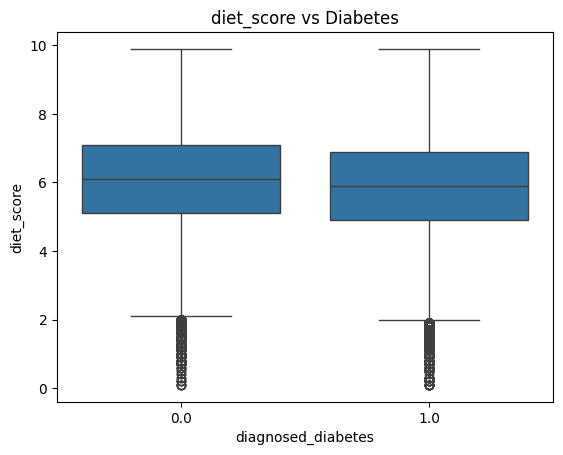

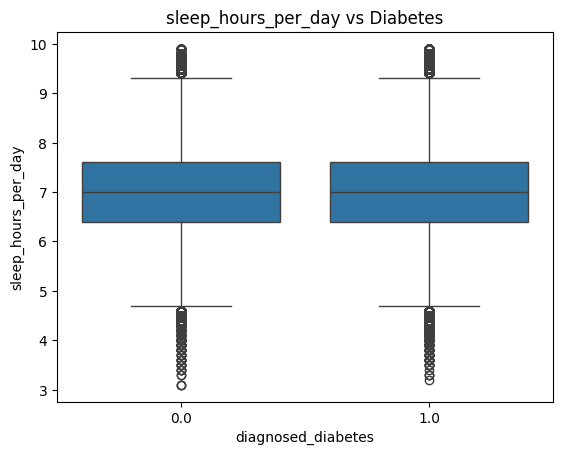

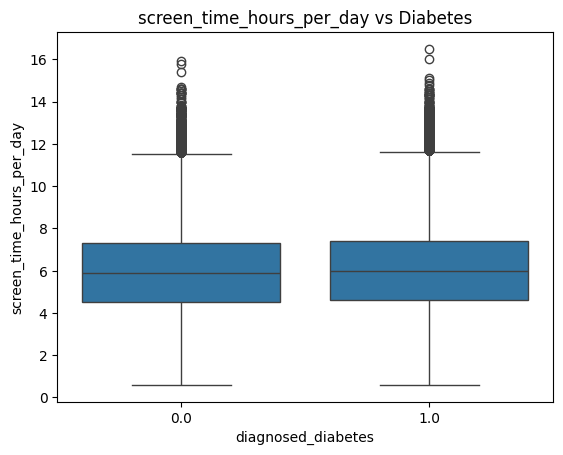

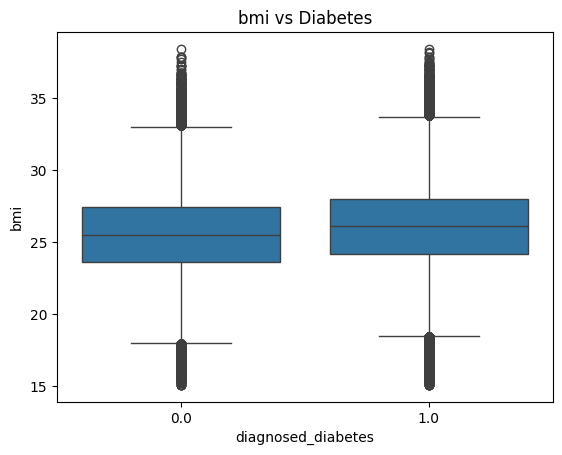

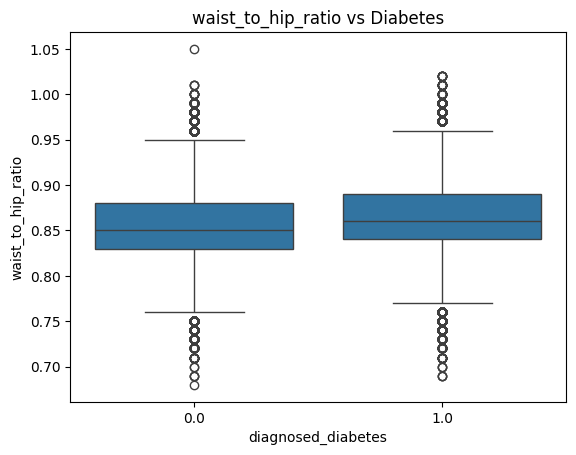

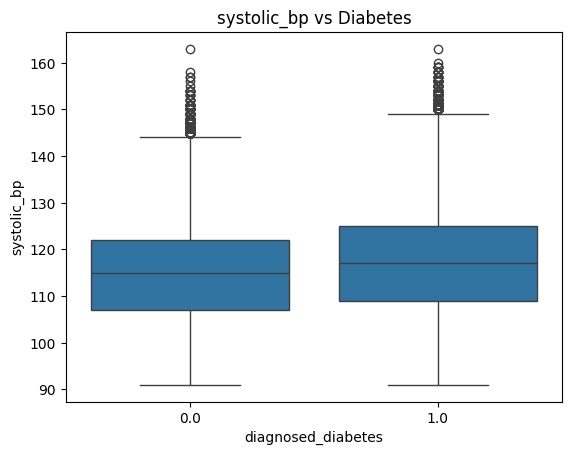

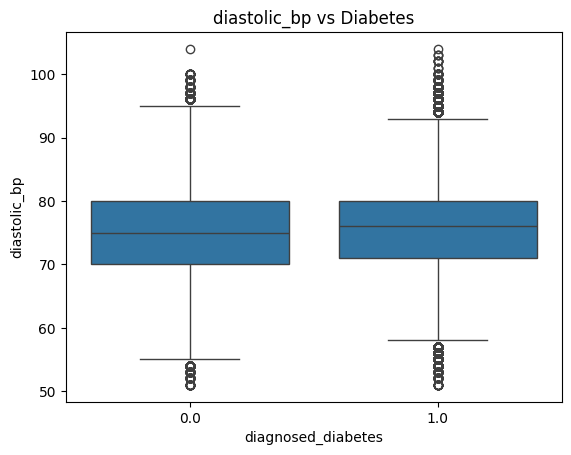

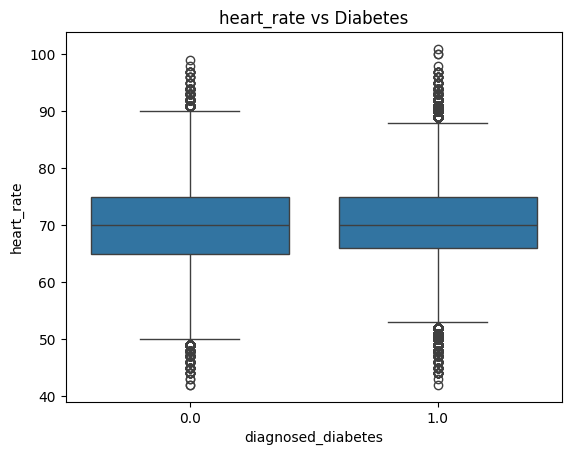

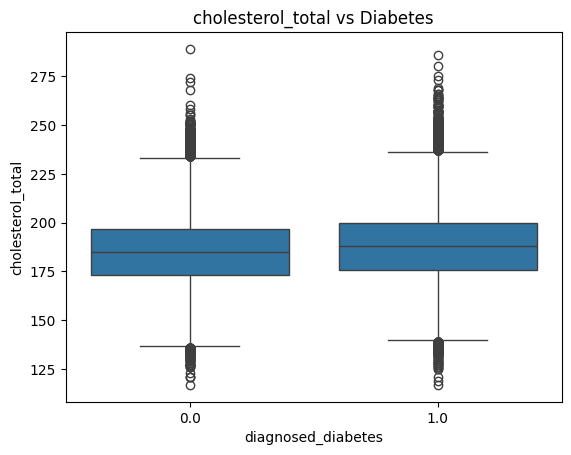

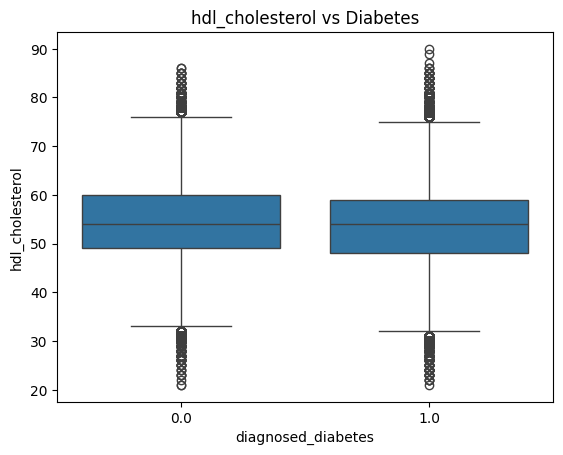

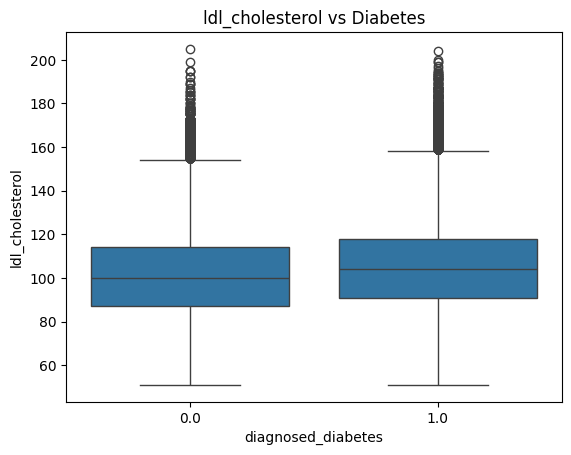

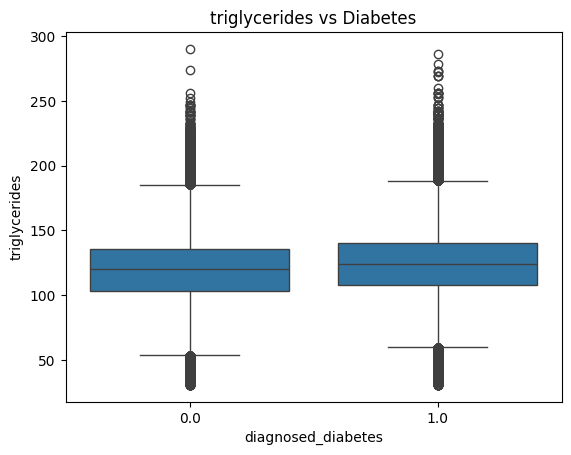

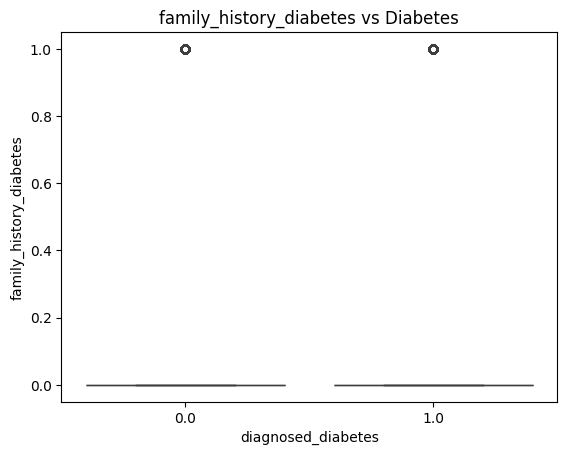

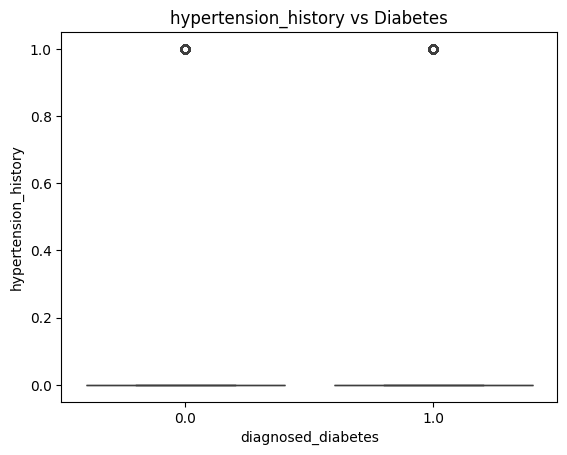

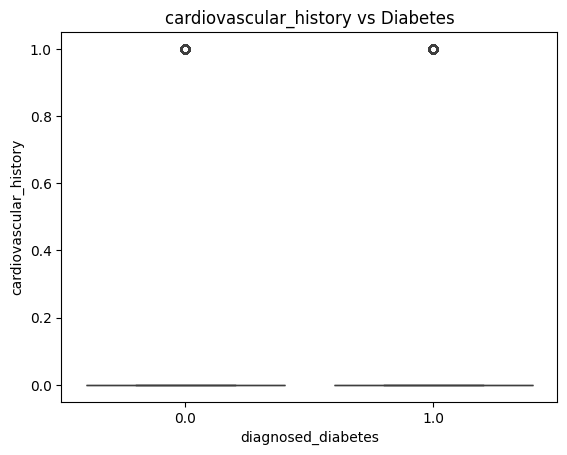

In [16]:
for col in n1:
    if col != target:
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f'{col} vs Diabetes')
        plt.show()


In [17]:
df[target]

0         1.0
1         1.0
2         0.0
3         1.0
4         1.0
         ... 
699995    0.0
699996    1.0
699997    1.0
699998    1.0
699999    1.0
Name: diagnosed_diabetes, Length: 700000, dtype: float64

In [18]:
for col in c1:
    # Crosstab
    ct = pd.crosstab(df[col], df['diagnosed_diabetes'])
    ct_perc = (ct.T / ct.sum(axis=1)).T * 100
    print(f"\n===== Crosstab: {col} vs Diagnosed Diabetics =====")
    print(ct_perc.round(2))
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"Chi-Square Test for {col}: χ²={chi2:.2f}, p-value={p:.4f}")


===== Crosstab: gender vs Diagnosed Diabetics =====
diagnosed_diabetes    0.0    1.0
gender                          
Female              37.78  62.22
Male                37.57  62.43
Other               35.94  64.06
Chi-Square Test for gender: χ²=7.93, p-value=0.0190

===== Crosstab: ethnicity vs Diagnosed Diabetics =====
diagnosed_diabetes    0.0    1.0
ethnicity                       
Asian               37.15  62.85
Black               37.61  62.39
Hispanic            38.37  61.63
Other               36.41  63.59
White               37.59  62.41
Chi-Square Test for ethnicity: χ²=47.00, p-value=0.0000

===== Crosstab: employment_status vs Diagnosed Diabetics =====
diagnosed_diabetes    0.0    1.0
employment_status               
Employed            37.54  62.46
Retired             38.19  61.81
Student             37.84  62.16
Unemployed          37.79  62.21
Chi-Square Test for employment_status: χ²=18.03, p-value=0.0004

===== Crosstab: education_level vs Diagnosed Diabetics =====

In [19]:
cor =df[n1].corr()
cor

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history
age,1.000000,0.003295,-0.029101,-0.001898,-0.001286,-0.002313,0.062958,0.044654,0.502894,0.188403,0.004294,0.283155,0.002654,0.245503,0.043605,0.018417,0.177636,0.099604
alcohol_consumption_per_week,0.003295,1.000000,0.003010,0.003284,-0.000351,0.004797,-0.017552,-0.014716,-0.006472,-0.001502,0.002230,-0.003121,0.009062,-0.006305,0.099985,0.002069,-0.003983,-0.001566
physical_activity_minutes_per_week,-0.029101,0.003010,1.000000,0.008466,-0.006900,0.001754,-0.085086,-0.067508,-0.030908,-0.018341,-0.268426,-0.027439,0.015996,-0.033272,-0.045595,-0.035260,-0.005766,-0.002205
diet_score,-0.001898,0.003284,0.008466,1.000000,0.000882,0.000382,-0.198899,-0.150906,-0.038676,-0.028384,0.005116,-0.041622,0.043585,-0.055908,-0.101834,-0.005173,0.001112,0.002690
sleep_hours_per_day,-0.001286,-0.000351,-0.006900,0.000882,1.000000,0.005965,0.003380,0.000371,0.003995,0.001457,0.009711,0.001287,-0.000549,0.001452,-0.005351,0.002502,0.005092,0.002002
screen_time_hours_per_day,-0.002313,0.004797,0.001754,0.000382,0.005965,1.000000,0.002758,0.003393,0.004276,-0.004632,-0.000152,-0.003384,-0.003529,-0.000059,0.003124,0.004202,0.001416,0.000836
bmi,0.062958,-0.017552,-0.085086,-0.198899,0.003380,0.002758,1.000000,0.757191,0.225033,0.143702,0.009575,0.180075,-0.197702,0.241057,0.443837,0.006417,0.009471,0.003461
waist_to_hip_ratio,0.044654,-0.014716,-0.067508,-0.150906,0.000371,0.003393,0.757191,1.000000,0.171691,0.111056,0.008807,0.146030,-0.154951,0.193638,0.359802,0.004509,0.006384,0.000885
systolic_bp,0.502894,-0.006472,-0.030908,-0.038676,0.003995,0.004276,0.225033,0.171691,1.000000,0.132916,0.005208,0.196124,-0.039579,0.187003,0.125682,0.009284,0.093637,0.052653
diastolic_bp,0.188403,-0.001502,-0.018341,-0.028384,0.001457,-0.004632,0.143702,0.111056,0.132916,1.000000,0.003055,0.075185,-0.025440,0.075297,0.069475,0.003912,0.036673,0.016763


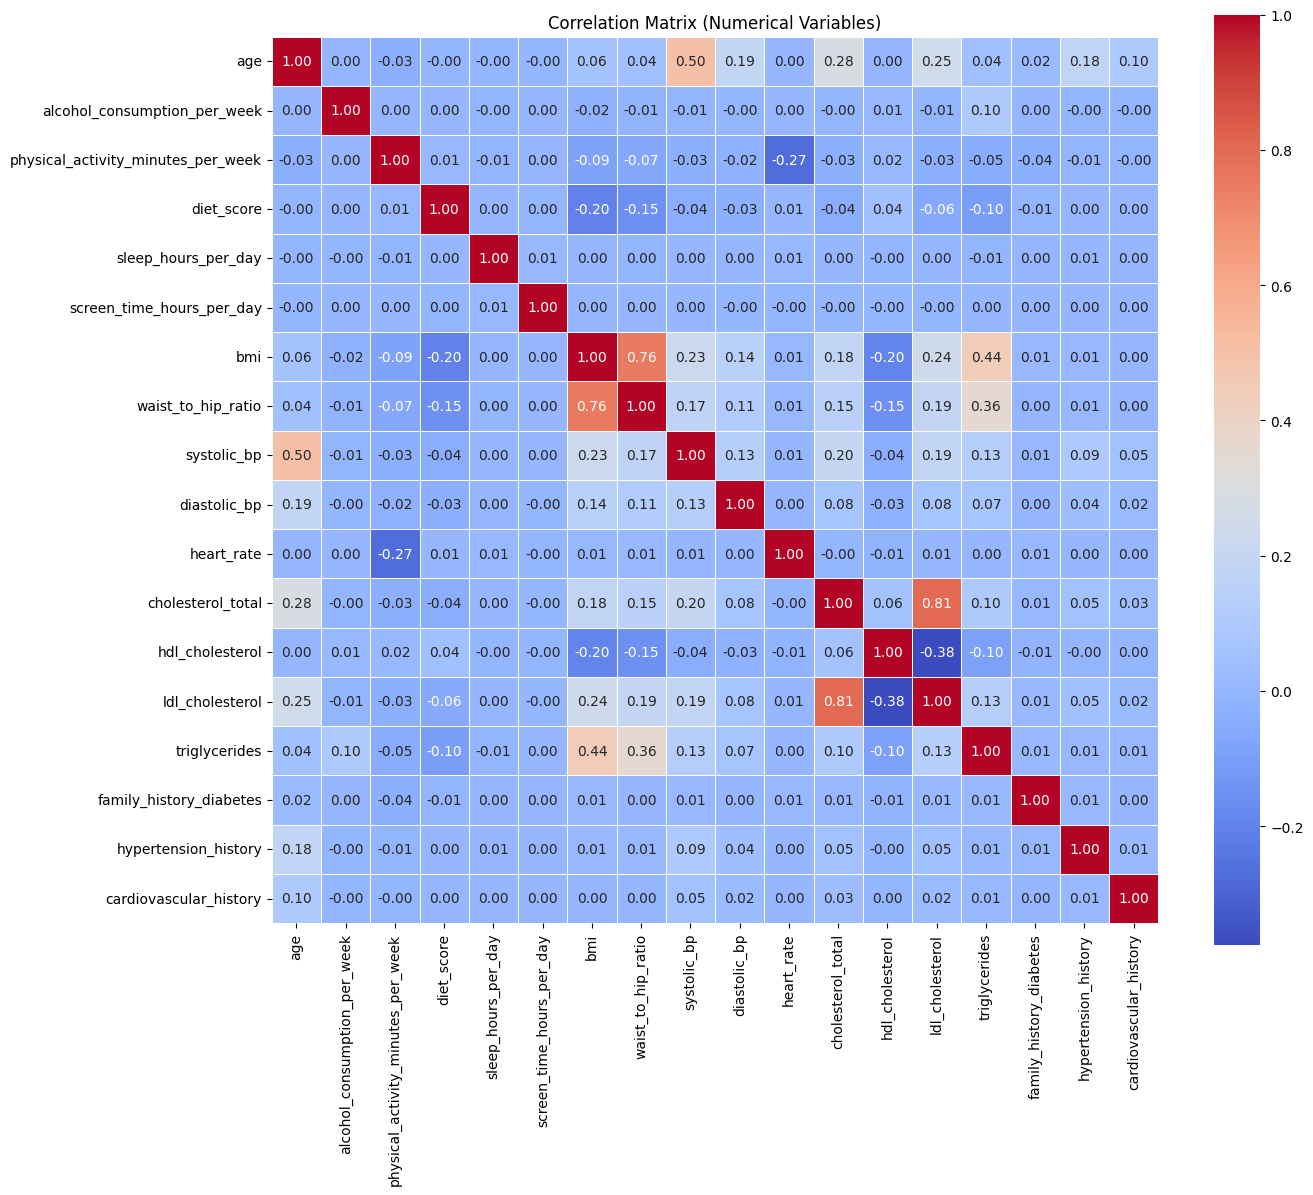

In [20]:
plt.figure(figsize=(14,12))
sns.heatmap(
    cor,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix (Numerical Variables)")
plt.tight_layout()

In [21]:
df[n1].skew().sort_values(ascending=False)


cardiovascular_history                5.477980
physical_activity_minutes_per_week    2.814197
family_history_diabetes               1.966986
hypertension_history                  1.648423
alcohol_consumption_per_week          0.932375
triglycerides                         0.192353
ldl_cholesterol                       0.132301
screen_time_hours_per_day             0.114110
systolic_bp                           0.097208
cholesterol_total                     0.061057
waist_to_hip_ratio                    0.037716
bmi                                   0.032107
age                                   0.020905
sleep_hours_per_day                   0.001486
diastolic_bp                         -0.001377
heart_rate                           -0.012544
hdl_cholesterol                      -0.021258
diet_score                           -0.062970
dtype: float64

In [22]:
skewed_features = [
    'physical_activity_minutes_per_week',
    'alcohol_consumption_per_week'
]
pt = PowerTransformer(method='yeo-johnson')
df[skewed_features] = pt.fit_transform(df[skewed_features])

In [23]:
df[c1]

,gender,ethnicity,employment_status,education_level,smoking_status,income_level
0,Female,Hispanic,Employed,Highschool,Current,Lower-Middle
1,Female,White,Employed,Highschool,Never,Upper-Middle
2,Male,Hispanic,Retired,Highschool,Never,Lower-Middle
3,Female,White,Employed,Highschool,Current,Lower-Middle
4,Male,White,Retired,Highschool,Never,Upper-Middle
...,...,...,...,...,...,...
699995,Female,Hispanic,Employed,Postgraduate,Former,Upper-Middle
699996,Female,Hispanic,Employed,Graduate,Former,Upper-Middle
699997,Female,White,Employed,Graduate,Never,Middle
699998,Female,White,Retired,Highschool,Never,Lower-Middle


In [24]:
nominal_cols = [
    'gender',
    'ethnicity',
    'employment_status',
    'smoking_status'
]

ordinal_cols = [
    'education_level',
    'income_level'
]
education_order = ['No formal','Highschool', 'Graduate', 'Postgraduate']
income_order = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']




In [25]:
numeric_transformer = RobustScaler()

nominal_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)

ordinal_transformer = OrdinalEncoder(
    categories=[education_order, income_order]
)


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, n1),
        ('nominal', nominal_transformer, nominal_cols),
        ('ordinal', ordinal_transformer, ordinal_cols)
    ]
)



In [27]:
df1 = df.drop(df.columns[:1], axis=1)

X_trained = df1.drop(columns=['diagnosed_diabetes'])



In [28]:
#X_trained = preprocessor.fit_transform(X)
#X_trained

Y_trained = df1['diagnosed_diabetes']
#X_train = pd.Dataframe(X_trained)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_trained, Y_trained,
    test_size=0.2,      
    random_state=42,    
    stratify=Y_trained        
)


In [30]:
model = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            
        ))
    ]
)

In [31]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best AUC:", grid.best_score_)
print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

Best AUC: 0.6934545781383894
Best params: {'classifier__C': 0.01}


In [32]:
best_model = grid.best_estimator_

In [33]:
rf = RandomForestClassifier(
    
    random_state=42
)

In [34]:
model1 = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', rf
        )
    ]
)

In [35]:
import os
os.cpu_count()

param_dist = {
    'classifier__n_estimators': [300]}


random_search = RandomizedSearchCV(
    model1,
    param_distributions=param_dist,
    n_iter=10,         
    scoring='roc_auc',
    cv=3,              
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
best_model1 = random_search.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__n_estimators': 300}


In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import  StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_model = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', GradientBoostingClassifier(
            random_state=42
        ))
    ]
)


In [37]:
param_dist = {
    # Gradient Boosting parameters
    'classifier__n_estimators': [300]}
    #'classifier__learning_rate': [0.01, 0.05, 0.1],
    #'classifier__max_depth': [2, 3, 4],
    #'classifier__subsample': [0.8, 1.0],

    # OPTIONAL: if your preprocessor has tunable params
    # Example:
    # 'preprocessing__num__scaler': [StandardScaler(), MinMaxScaler()]


rand_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=10,                 # keep small → fast
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_search.fit(X_train, y_train)
rand_search.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__n_estimators': 300}

In [38]:
best_model2 = rand_search.best_estimator_

In [39]:
from sklearn.metrics import roc_auc_score

models = {
    'Logistic Regression': best_model,
    'Random Forest': best_model1,
    'Gradient Boosting':best_model2
}

results = []

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results.append((name, auc))


In [40]:
results_df = pd.DataFrame(results, columns=['Model', 'Test ROC-AUC'])
results_df.sort_values(by='Test ROC-AUC', ascending=False)


,Model,Test ROC-AUC
2,Gradient Boosting,0.719299
1,Random Forest,0.698870
0,Logistic Regression,0.693837


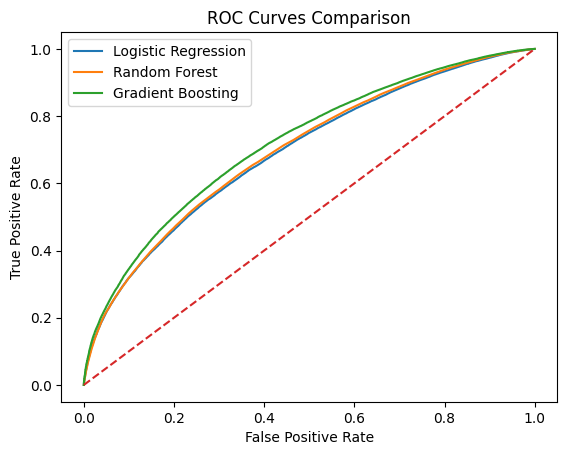

In [41]:
from sklearn.metrics import roc_curve


plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curves Comparison")
plt.show()


In [42]:
df1= pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")

In [43]:
skewed_features = [
    'physical_activity_minutes_per_week',
    'alcohol_consumption_per_week'
]
pt = PowerTransformer(method='yeo-johnson')
df1[skewed_features] = pt.fit_transform(df1[skewed_features])

In [44]:
predictions= best_model2.predict_proba(df1)[:, 1]

submission = pd.DataFrame({
    "id": df1["id"],
    "diagnosed_diabetes": predictions
})

submission.to_csv("sample_submission.csv", index=False)
print("\nSaved submission.csv")


Saved submission.csv
